In [35]:
lst = [{"thread_id": "1", "smart_name": "New Chat"},{"thread_id": "2", "smart_name": "Java Code"},{"thread_id": "3", "smart_name": "Python Code"}]
# print(lst)
data = {"thread_id": "4", "smart_name": "New Chat"}
# exist = False
# for item in lst:
#     if item['thread_id'] == data['thread_id']:
#         exist=True  
# if not exist:
#     lst.append(data)



# if any(data['thread_id'] == item['thread_id'] for item in lst)

In [32]:
any([False, True, False])

True

In [36]:
any(data['thread_id'] == item['thread_id'] for item in lst)

False

In [37]:
[data['thread_id'] == item['thread_id'] for item in lst]

[False, False, False]

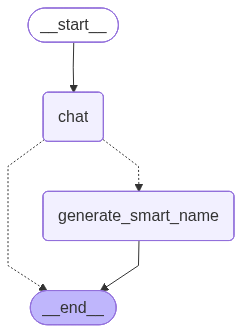

In [40]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated, Literal
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
load_dotenv()

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    smart_name: str
    boolean_to_create_smart_name: bool

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

def chat(state: ChatState) -> ChatState:
    messages = state["messages"]
    responce = llm.invoke(messages)
    return {"messages": responce}

def generate_smart_name(state: ChatState) -> ChatState:
    messages = state['messages']
    responce = llm.invoke(f"Return one short title for this conversation: {messages}").content[0]["text"]
    return {"smart_name": responce}

def handle_condition(state: ChatState) -> Literal["generate_smart_name", "__end__"]:
    if state['boolean_to_create_smart_name']:
        return "generate_smart_name"
    else:
        return "__end__"
graph = StateGraph(ChatState)

graph.add_node("chat", chat)
graph.add_node("generate_smart_name", generate_smart_name)

graph.add_edge(START, 'chat')
graph.add_conditional_edges("chat", handle_condition)
graph.add_edge('chat', END)
graph.add_edge("generate_smart_name", END)

checkpoint = InMemorySaver()

chat_gemini = graph.compile(checkpointer=checkpoint)
chat_gemini


# user_config = {"configurable": {"thread_id": 'thread_1'}}
# responce = chat_gemini.invoke(
#             input={"messages": HumanMessage(content="Hii")},
#             config=user_config
#         )

# convos = chat_gemini.get_state(config=user_config)
# print(convos.values['messages'][0].content)


In [1]:
import platform
platform.system()

'Linux'